# Optimization applied to a linear system

Original source code by [Rahul Halder](https://github.com/rahulhalderAERO/DisPINN3/tree/main)

In [1]:
import pickle as pkl
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_size//2, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size//2, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size//2, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size//2, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [3]:
class LinearModel(nn.Module):
    def __init__(self, bias: bool = False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 1, bias=bias),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)
    

In [4]:
with open("outputs/opt_state/optimizer_results_linearmodel_purephys.pkl", "rb") as f:
    results_phys = pkl.load(f)
with open("outputs/opt_state/optimizer_results_linearmodel_puredata.pkl", "rb") as f:
    results_data = pkl.load(f)
with open("outputs/opt_state/optimizer_results_linearmodel_mix.pkl", "rb") as f:
    results_mix = pkl.load(f)

In [7]:
# fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# for results in [results_phys, results_data, results_mix]:
#     for i, opt_name in enumerate(results):
#         loss_avg = np.mean(results[opt_name]["loss_histories"], axis = 1)
#         loss_std = np.std(results[opt_name]["loss_histories"], axis = 1)
#         ax.plot(loss_avg, label=opt_name)
#         ax.fill_between(range(len(loss_avg)),                    
#                         loss_avg - loss_std,
#                         loss_avg + loss_std, alpha=0.2)
# ax.set_title("Training Loss", fontsize=20)
# ax.set_yscale("log")
# ax.set_xlabel("Epoch", fontsize=18)
# ax.set_ylabel("MSE Loss", fontsize=18)
# ax.legend(fontsize=14)

# plt.savefig("./outputs/plots/soap_preconditioning_frequency.png")

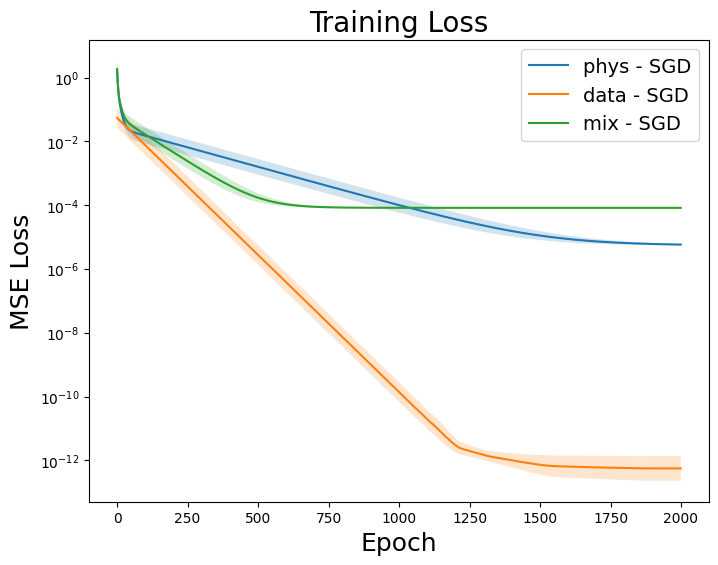

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
name = ["phys", "data", "mix"]
for i, results in enumerate([results_phys, results_data, results_mix]):
    for j, opt_name in enumerate(results):
        loss_avg = np.mean(results[opt_name]["loss_histories"], axis = 1)
        loss_std = np.std(results[opt_name]["loss_histories"], axis = 1)
        lower = loss_avg / (1 + loss_std / loss_avg)
        upper = loss_avg * (1 + loss_std / loss_avg)
        ax.plot(loss_avg, label=f"{name[i]} - {opt_name}")
        ax.fill_between(range(len(loss_avg)),                    
                        lower,
                        upper, alpha=0.2)
ax.set_title("Training Loss", fontsize=20)
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.legend(fontsize=14)

plt.savefig("./outputs/plots/soapw_scaledphys.png")